# 📐 Step 3 — OLS Regression: Assumptions & Diagnostics

> **Goal:** Fit the baseline OLS model, test every Gauss-Markov assumption,
> and visually diagnose where the model succeeds or struggles.

---
### The Gauss-Markov Assumptions we will test

| # | Assumption | Test |
|---|---|---|
| 1 | Linearity | Scatter + fitted line |
| 2 | Independence | Durbin-Watson (≈ 2 is ideal) |
| 3 | Homoscedasticity | Residuals vs Fitted plot, Breusch-Pagan |
| 4 | Normality of residuals | Q-Q plot, Shapiro-Wilk |
| 5 | No perfect multicollinearity | VIF scores |


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import probplot, shapiro

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#2e3347', 'axes.labelcolor': '#c8ccd8',
    'axes.titlecolor': '#e8eaf0', 'xtick.color': '#8890a8',
    'ytick.color': '#8890a8', 'grid.color': '#2e3347',
    'grid.linewidth': 0.6, 'text.color': '#e8eaf0',
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'figure.dpi': 130,
})

ACCENT  = '#4fc3f7'
ACCENT2 = '#ff6b6b'
ACCENT3 = '#a5d6a7'
ACCENT4 = '#ffb74d'

df = pd.read_csv(r"C:\Users\DELL\Downloads\files (3)\df_features.csv")

FEATURES = [
    'log_gdp', 'log_population', 'poverty_headcount', 'secondary_enrollment',
    'unemployment_rate', 'inequality_measure', 'governance_avg',
    'stress_x_weak', 'political_stability',
]
TARGET_LOG = 'log_attacks'

sub = df[FEATURES + [TARGET_LOG, 'attacks']].dropna()
X   = sub[FEATURES].values
y   = sub[TARGET_LOG].values

print(f'Modelling dataset: {len(sub):,} rows')

Modelling dataset: 2,742 rows


## 3.1 Fit OLS model

In [3]:
pipe = Pipeline([
    ('imp',   SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('ols',   LinearRegression()),
])
pipe.fit(X, y)

y_pred   = pipe.predict(X)
residuals = y - y_pred

r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae  = mean_absolute_error(y, y_pred)
n    = len(y)
p    = len(FEATURES)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f'R²          = {r2:.4f}')
print(f'Adjusted R² = {adj_r2:.4f}')
print(f'RMSE (log)  = {rmse:.4f}')
print(f'MAE  (log)  = {mae:.4f}')

# Extract coefficients (they are on standardised scale)
ols_model = pipe.named_steps['ols']
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': ols_model.coef_,
}).sort_values('Coefficient')

print('\nCoefficients (standardised):')
print(coef_df.to_string(index=False))

R²          = 0.4129
Adjusted R² = 0.4109
RMSE (log)  = 1.3243
MAE  (log)  = 1.0055

Coefficients (standardised):
             Feature  Coefficient
 political_stability    -0.977039
   poverty_headcount    -0.364315
secondary_enrollment    -0.183044
             log_gdp    -0.013803
       stress_x_weak     0.020591
   unemployment_rate     0.041760
  inequality_measure     0.049033
      governance_avg     0.684302
      log_population     0.873193


## 3.2 Assumption 1 — Linearity

Plot each predictor against the residuals. A truly linear relationship should show 
**random scatter around zero** — no curves, no funnels.

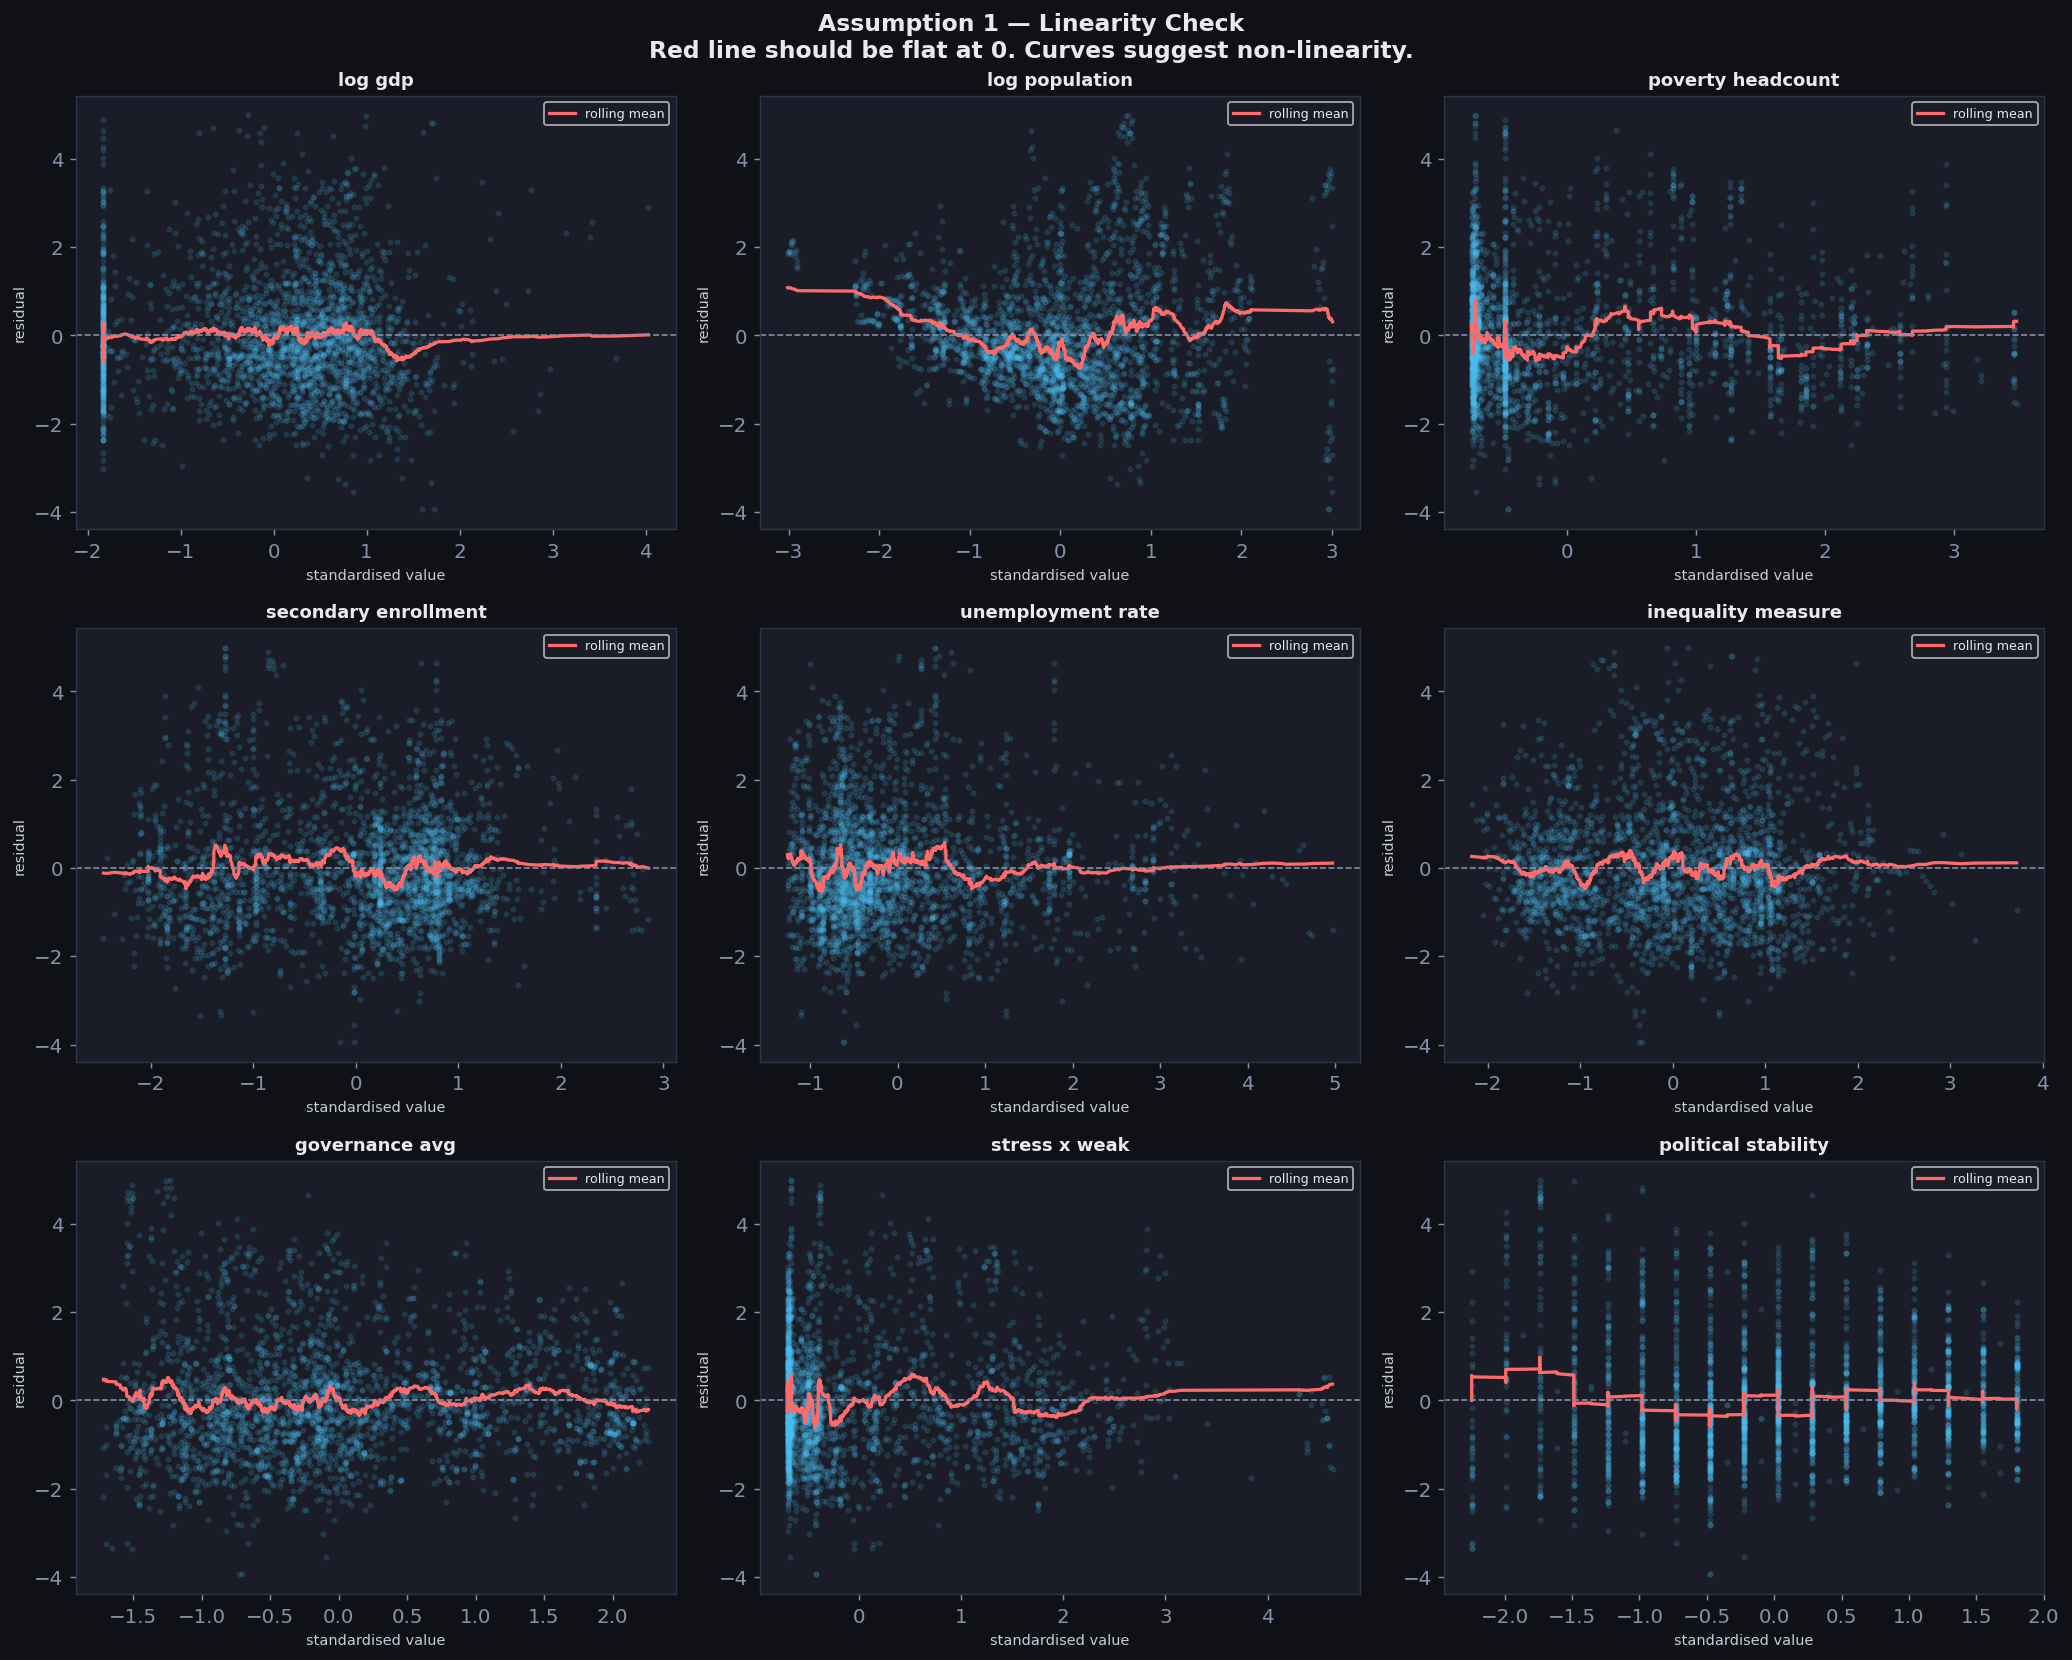

In [4]:
imp   = pipe.named_steps['imp']
scale = pipe.named_steps['scale']
X_imp = scale.transform(imp.transform(X))

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for ax, feat, xi in zip(axes.flat, FEATURES, X_imp.T):
    ax.scatter(xi, residuals, alpha=0.12, s=6, color=ACCENT)
    # LOWESS-style rolling mean to detect non-linearity
    idx_sort = np.argsort(xi)
    window   = len(xi) // 20
    roll_med = pd.Series(residuals[idx_sort]).rolling(window, center=True, min_periods=5).mean()
    ax.plot(xi[idx_sort], roll_med.values, color=ACCENT2, lw=1.8, label='rolling mean')
    ax.axhline(0, color='#8890a8', lw=0.9, ls='--')
    ax.set_title(feat.replace('_', ' '), fontsize=10)
    ax.set_xlabel('standardised value', fontsize=8)
    ax.set_ylabel('residual', fontsize=8)
    ax.legend(fontsize=7)

fig.suptitle('Assumption 1 — Linearity Check\n'
             'Red line should be flat at 0. Curves suggest non-linearity.',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.3 Assumption 3 — Homoscedasticity

Residuals should show **constant variance** across fitted values. 
A funnel shape (variance increasing with fitted value) indicates heteroscedasticity 
and inflates standard errors.

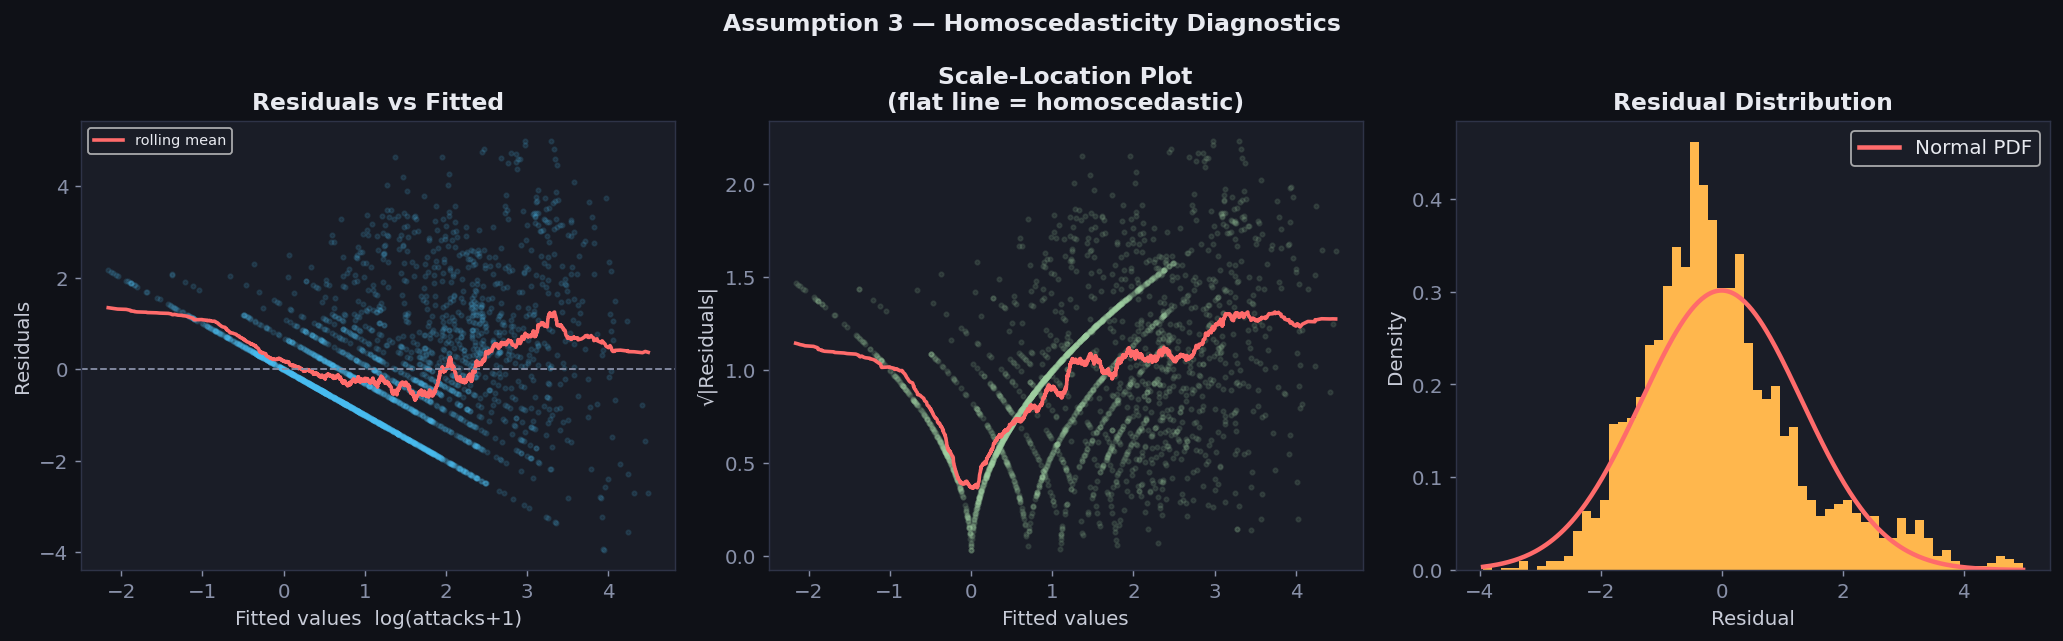

Breusch-Pagan proxy: r(|residuals|, fitted) = 0.431, p = 0.0000
→ Evidence of heteroscedasticity


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Residuals vs Fitted
ax = axes[0]
ax.scatter(y_pred, residuals, alpha=0.12, s=6, color=ACCENT)
idx_sort = np.argsort(y_pred)
window   = len(y_pred) // 20
roll_med = pd.Series(residuals[idx_sort]).rolling(window, center=True, min_periods=5).mean()
ax.plot(y_pred[idx_sort], roll_med.values, color=ACCENT2, lw=2, label='rolling mean')
ax.axhline(0, color='#8890a8', lw=1, ls='--')
ax.set_xlabel('Fitted values  log(attacks+1)')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted')
ax.legend(fontsize=8)

# Plot 2: Scale-Location (sqrt |residuals| vs fitted)
ax = axes[1]
sqrt_abs_res = np.sqrt(np.abs(residuals))
ax.scatter(y_pred, sqrt_abs_res, alpha=0.12, s=6, color=ACCENT3)
roll_sl = pd.Series(sqrt_abs_res[idx_sort]).rolling(window, center=True, min_periods=5).mean()
ax.plot(y_pred[idx_sort], roll_sl.values, color=ACCENT2, lw=2)
ax.set_xlabel('Fitted values')
ax.set_ylabel('√|Residuals|')
ax.set_title('Scale-Location Plot\n(flat line = homoscedastic)')

# Plot 3: Residual distribution
ax = axes[2]
ax.hist(residuals, bins=60, color=ACCENT4, edgecolor='none', density=True)
xr = np.linspace(residuals.min(), residuals.max(), 300)
ax.plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()),
        color=ACCENT2, lw=2.5, label='Normal PDF')
ax.set_xlabel('Residual')
ax.set_ylabel('Density')
ax.set_title('Residual Distribution')
ax.legend()

fig.suptitle('Assumption 3 — Homoscedasticity Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Breusch-Pagan proxy: correlation between |residuals| and fitted
bp_r, bp_p = stats.pearsonr(np.abs(residuals), y_pred)
print(f'Breusch-Pagan proxy: r(|residuals|, fitted) = {bp_r:.3f}, p = {bp_p:.4f}')
print('→ ' + ('Evidence of heteroscedasticity' if bp_p < 0.05 else 'No strong heteroscedasticity'))

## 3.4 Assumption 4 — Normality of residuals

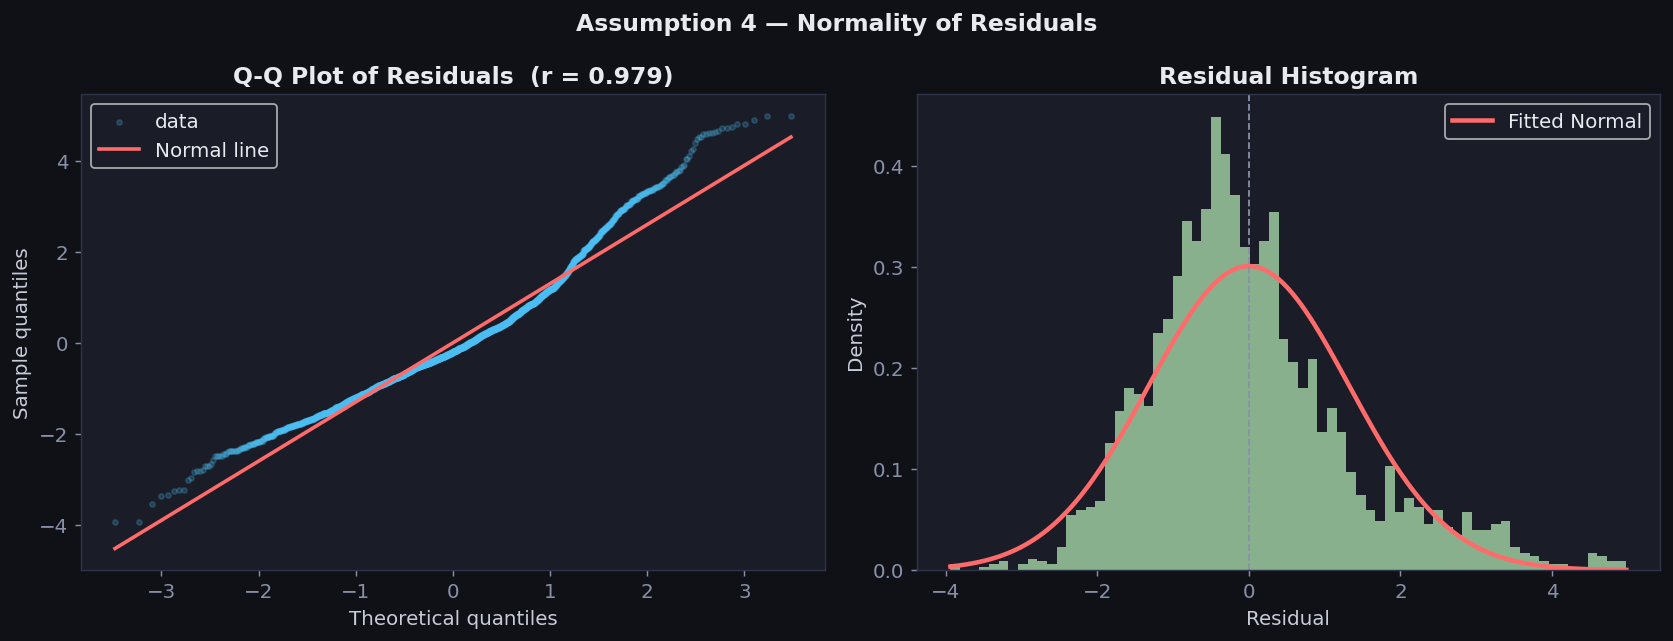

Shapiro-Wilk test:  W = 0.9591,  p = 0.0000
→ Residuals deviate from normality
Skewness = 0.820   Kurtosis = 0.993


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Q-Q plot
ax = axes[0]
(osm, osr), (slope, intercept, r_qq) = probplot(residuals, dist='norm')
ax.scatter(osm, osr, alpha=0.2, s=8, color=ACCENT, label='data')
line_y = slope * np.array([osm.min(), osm.max()]) + intercept
ax.plot([osm.min(), osm.max()], line_y, color=ACCENT2, lw=2, label='Normal line')
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')
ax.set_title(f'Q-Q Plot of Residuals  (r = {r_qq:.3f})')
ax.legend()

# Histogram with fitted normal
ax = axes[1]
ax.hist(residuals, bins=70, color=ACCENT3, edgecolor='none', density=True, alpha=0.8)
xr = np.linspace(residuals.min(), residuals.max(), 300)
ax.plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()),
        color=ACCENT2, lw=2.5, label='Fitted Normal')
ax.axvline(0, color='#8890a8', lw=1, ls='--')
ax.set_xlabel('Residual')
ax.set_ylabel('Density')
ax.set_title('Residual Histogram')
ax.legend()

fig.suptitle('Assumption 4 — Normality of Residuals', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Shapiro-Wilk on a sample (max 5000)
sample = residuals[:5000] if len(residuals) > 5000 else residuals
stat, pval = shapiro(sample)
print(f'Shapiro-Wilk test:  W = {stat:.4f},  p = {pval:.4f}')
print('→ ' + ('Residuals deviate from normality' if pval < 0.05 else 'Residuals appear normal'))
print(f'Skewness = {pd.Series(residuals).skew():.3f}   Kurtosis = {pd.Series(residuals).kurt():.3f}')

## 3.5 Assumption 5 — Variance Inflation Factor (VIF)

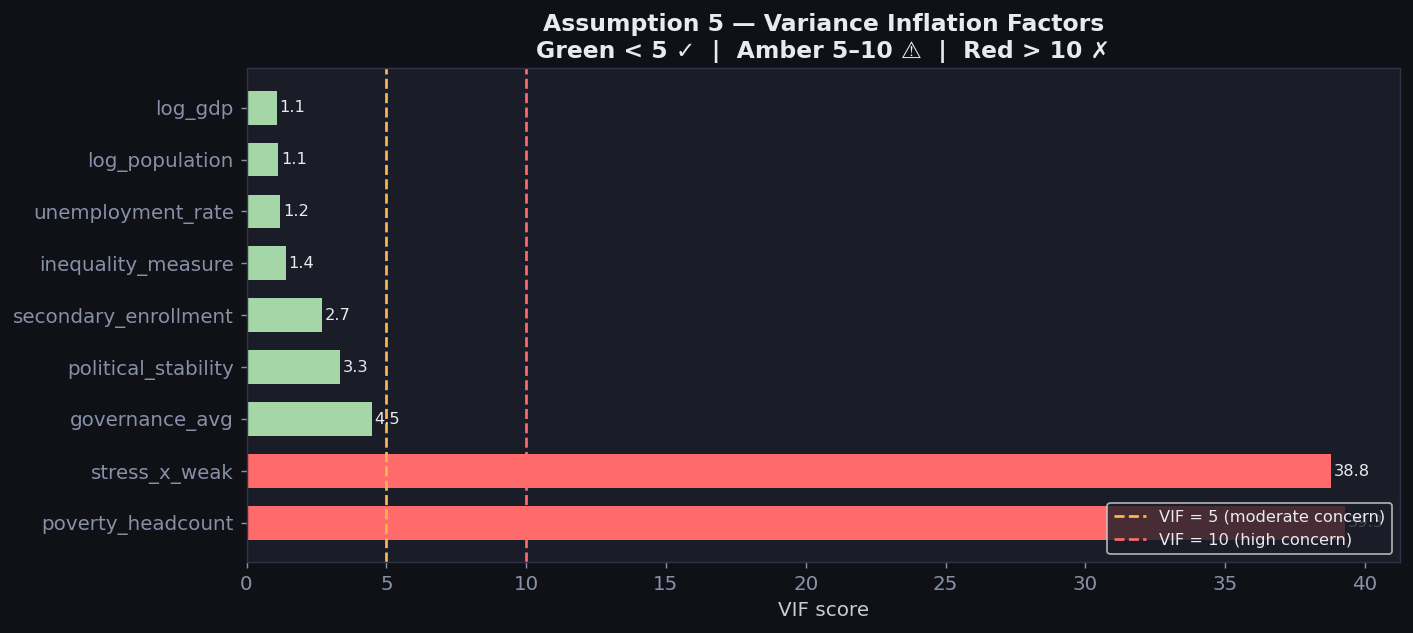

             Feature   VIF
   poverty_headcount 39.29
       stress_x_weak 38.77
      governance_avg  4.47
 political_stability  3.34
secondary_enrollment  2.69
  inequality_measure  1.41
   unemployment_rate  1.21
      log_population  1.13
             log_gdp  1.08


In [7]:
from sklearn.linear_model import LinearRegression as LR

def compute_vif(X_scaled, feature_names):
    vifs = []
    for i in range(X_scaled.shape[1]):
        X_other = np.delete(X_scaled, i, axis=1)
        r2_i    = LR().fit(X_other, X_scaled[:, i]).score(X_other, X_scaled[:, i])
        vifs.append(1 / (1 - r2_i) if r2_i < 1 else np.inf)
    return pd.DataFrame({'Feature': feature_names, 'VIF': np.round(vifs, 2)})

vif_df = compute_vif(X_imp, FEATURES).sort_values('VIF', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = [ACCENT2 if v > 10 else ACCENT4 if v > 5 else ACCENT3 for v in vif_df['VIF']]
ax.barh(vif_df['Feature'], vif_df['VIF'],
        color=bar_colors, edgecolor='none', height=0.65)
ax.axvline(5,  color=ACCENT4,  lw=1.5, ls='--', label='VIF = 5 (moderate concern)')
ax.axvline(10, color=ACCENT2,  lw=1.5, ls='--', label='VIF = 10 (high concern)')
for i, (feat, vif) in enumerate(zip(vif_df['Feature'], vif_df['VIF'])):
    ax.text(vif + 0.1, i, f'{vif:.1f}', va='center', fontsize=9, color='#e8eaf0')
ax.set_xlabel('VIF score')
ax.set_title('Assumption 5 — Variance Inflation Factors\n'
             'Green < 5 ✓  |  Amber 5–10 ⚠  |  Red > 10 ✗')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print(vif_df.to_string(index=False))

## 3.6 Actual vs Predicted — overall fit

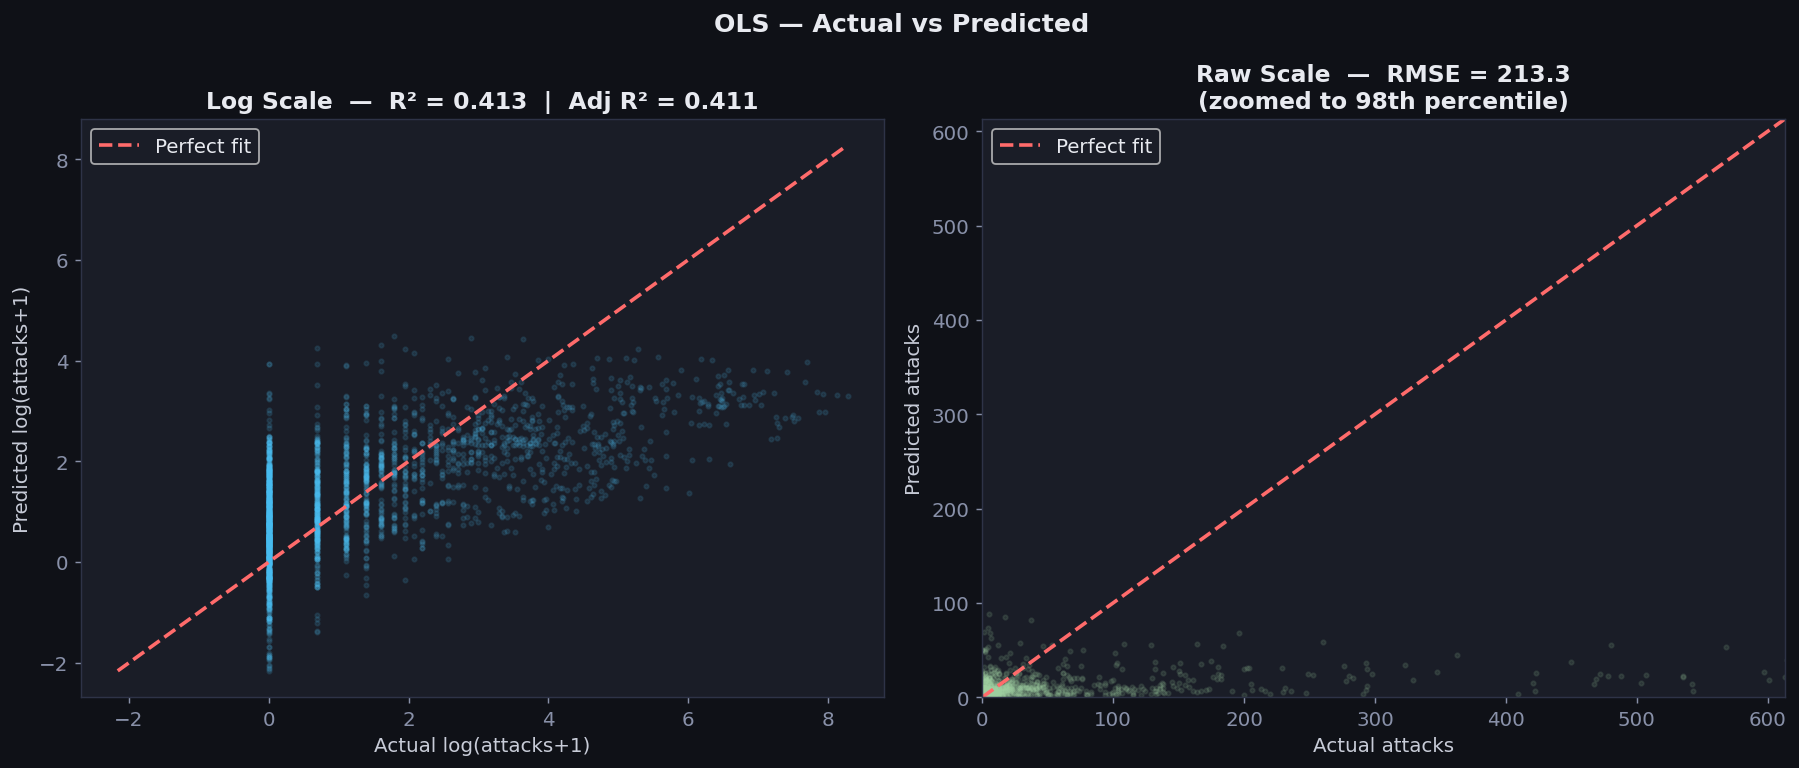


Summary metrics:
  R²                  = 0.4129
  Adjusted R²         = 0.4109
  RMSE (log scale)    = 1.3243
  MAE  (log scale)    = 1.0055
  RMSE (raw scale)    = 213.34 attacks


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Log scale
ax = axes[0]
ax.scatter(y, y_pred, alpha=0.12, s=6, color=ACCENT)
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
ax.plot(lims, lims, color=ACCENT2, lw=2, ls='--', label='Perfect fit')
ax.set_xlabel('Actual log(attacks+1)')
ax.set_ylabel('Predicted log(attacks+1)')
ax.set_title(f'Log Scale  —  R² = {r2:.3f}  |  Adj R² = {adj_r2:.3f}')
ax.legend()

# Raw scale (back-transform)
ax = axes[1]
y_raw   = sub['attacks'].values
y_pred_raw = np.maximum(np.expm1(y_pred), 0)
ax.scatter(y_raw, y_pred_raw, alpha=0.12, s=6, color=ACCENT3)
lims_r = [0, np.percentile(y_raw, 98)]  # zoom in to avoid outlier distortion
ax.plot(lims_r, lims_r, color=ACCENT2, lw=2, ls='--', label='Perfect fit')
ax.set_xlim(*lims_r); ax.set_ylim(*lims_r)
ax.set_xlabel('Actual attacks')
ax.set_ylabel('Predicted attacks')
rmse_raw = np.sqrt(mean_squared_error(y_raw, y_pred_raw))
ax.set_title(f'Raw Scale  —  RMSE = {rmse_raw:.1f}\n(zoomed to 98th percentile)')
ax.legend()

fig.suptitle('OLS — Actual vs Predicted', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nSummary metrics:')
print(f'  R²                  = {r2:.4f}')
print(f'  Adjusted R²         = {adj_r2:.4f}')
print(f'  RMSE (log scale)    = {rmse:.4f}')
print(f'  MAE  (log scale)    = {mae:.4f}')
print(f'  RMSE (raw scale)    = {rmse_raw:.2f} attacks')

## 3.7 Coefficient plot — which predictors matter most?

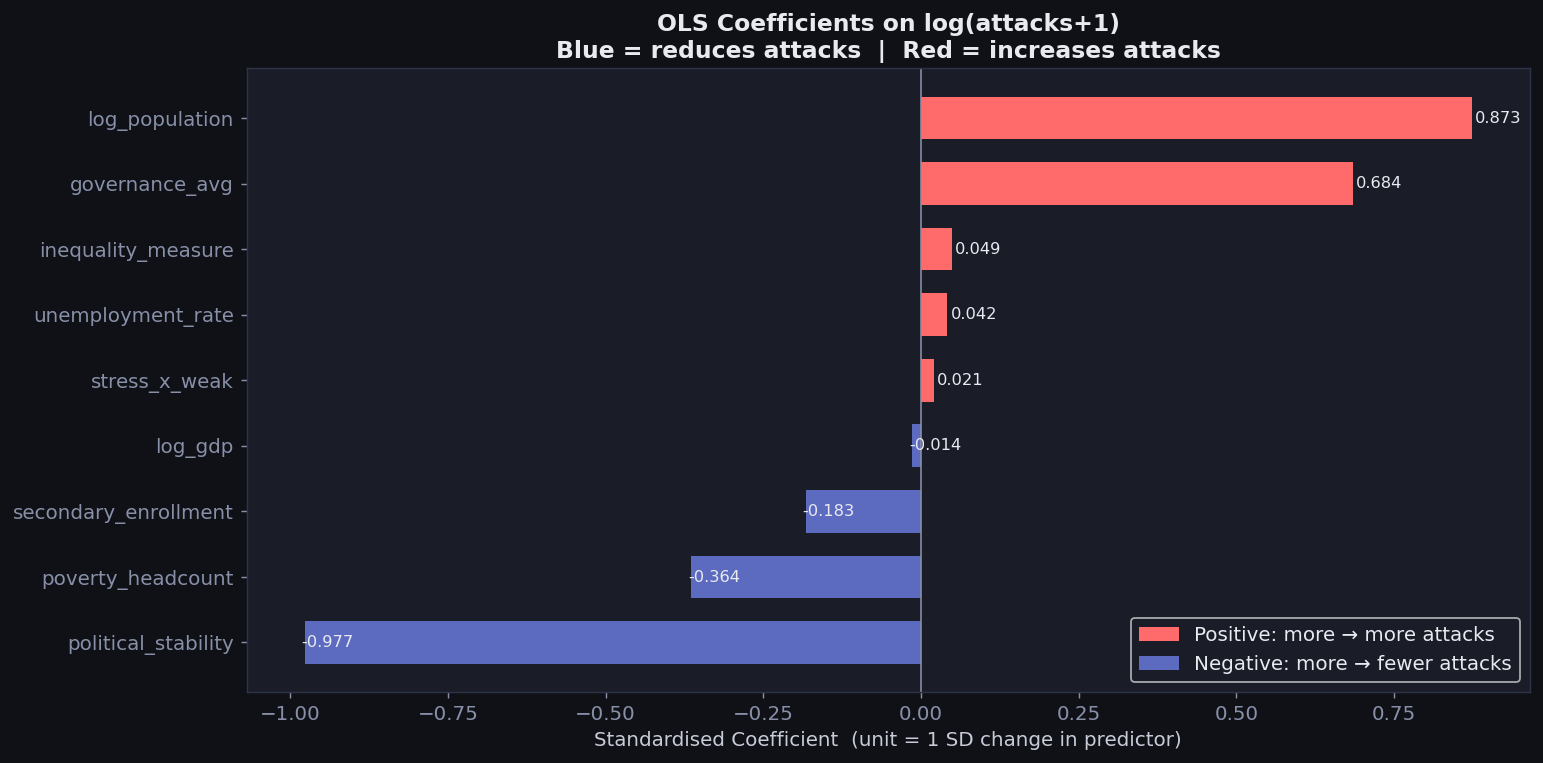

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
coef_sorted = coef_df.sort_values('Coefficient')
colors = [ACCENT2 if c > 0 else '#5c6bc0' for c in coef_sorted['Coefficient']]
bars = ax.barh(coef_sorted['Feature'], coef_sorted['Coefficient'],
               color=colors, edgecolor='none', height=0.65)
ax.axvline(0, color='#8890a8', lw=0.9)
for bar, val in zip(bars, coef_sorted['Coefficient']):
    xpos = bar.get_width() + 0.005 if val >= 0 else bar.get_width() - 0.005
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, color='#e8eaf0')
ax.set_xlabel('Standardised Coefficient  (unit = 1 SD change in predictor)')
ax.set_title('OLS Coefficients on log(attacks+1)\n'
             'Blue = reduces attacks  |  Red = increases attacks')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=ACCENT2,   label='Positive: more → more attacks'),
    Patch(facecolor='#5c6bc0', label='Negative: more → fewer attacks'),
], loc='lower right')
plt.tight_layout()
plt.show()

In [10]:
# Save residuals and predictions for use in later notebooks
sub2 = sub.copy()
sub2['ols_pred_log'] = y_pred
sub2['ols_residual'] = residuals
sub2.to_csv('df_ols.csv', index=False)
print('OLS diagnostics complete. Saved to /tmp/df_ols.csv')
print('Ready for Step 4 ✓')

OLS diagnostics complete. Saved to /tmp/df_ols.csv
Ready for Step 4 ✓
